# BlueQubit hackathon. Task 2.

Here the circuit is bigger than 36 quibts (maximum for GPU device).
I found that 6 qubits can be measured earlier and then can be reused. Below is the schematic of the circuit reorganization.
The initial circuit can be represented as follows:
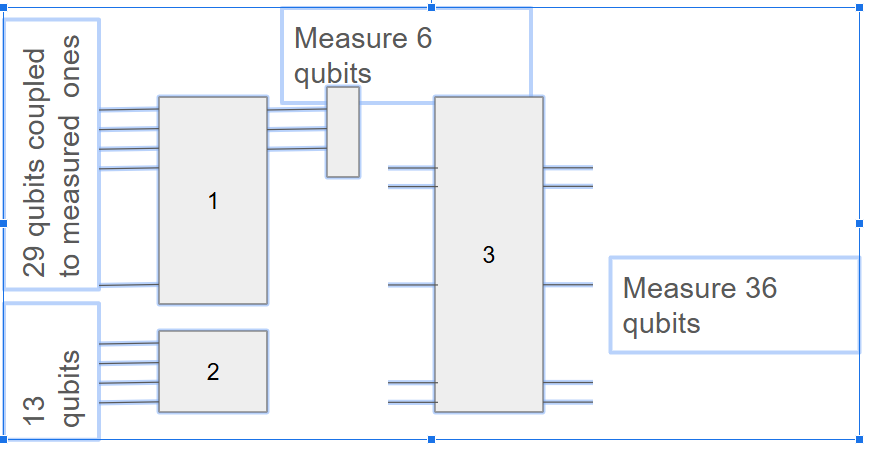
The reorgainized circuit has only 36 quibits and can be run on GPUs.
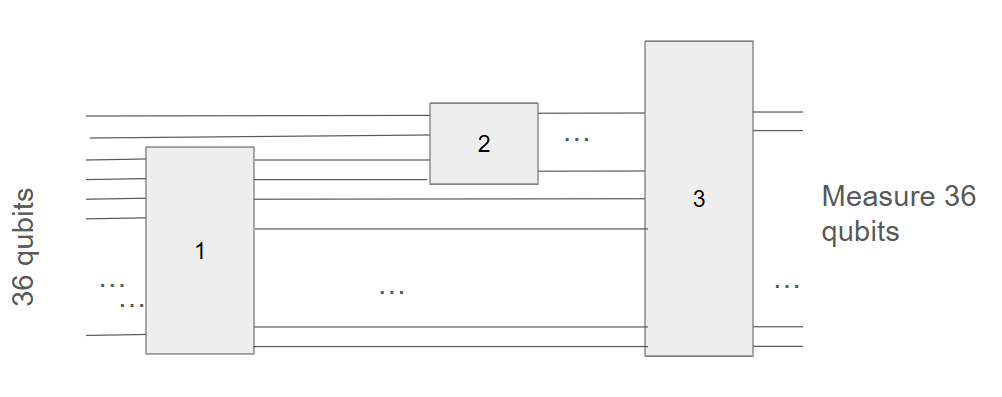

The 6 quibits are coupled to other but not all the quibit. So, we can run that part of the circuit and get 6 bits of the bitstring. THey all |0>, making reorganization easier.
Then I reorginize the circuit and run it on GPUs.


There is a special function below that get the graph of coupling. This allows to include all necessary quibit when we try to measure first 6 ones.


In [2]:
#!pip install stimcirq ply

In [3]:
#importing libraries
import numpy as np
import time
import sys
import math

import qiskit
from qiskit import QuantumRegister as Q_R
from qiskit import ClassicalRegister as C_R
from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile


import stim
import stimcirq
from cirq.contrib.qasm_import import circuit_from_qasm

In [11]:
#load circuit from a file
import qiskit.qasm2
 
#q = qiskit.qasm2.load("circuit_1_30q.qasm")
with open('circuit_1_30q.qasm', 'r') as file:
    # Read the entire content of the file
    content = file.read()
    # Alternatively, read all lines into a list
    # content = file.readlines()
    # Or read line by line
    # line = file.readline()

# Now you can work with the content
print(content)

OPENQASM 2.0;
include "qelib1.inc";
qreg q[30];
creg c[30];
rz(2.353304971691044) q[29];
sx q[29];
rz(5.9735141613602165) q[29];
sx q[29];
x q[29];
rz(4.599253580133889) q[29];
rz(3.761482191925223) q[28];
sx q[28];
rz(0.980294029274052) q[28];
sx q[28];
x q[28];
rz(0.9801424781769557) q[28];
cz q[29],q[28];
rz(0.3649500985631483) q[27];
sx q[27];
rz(5.442345232562516) q[27];
sx q[27];
x q[27];
rz(3.776917009710014) q[27];
rz(4.448951217224888) q[26];
sx q[26];
rz(0.12933619211510794) q[26];
sx q[26];
x q[26];
rz(6.094123332392967) q[26];
cz q[27],q[26];
rz(5.230391369746984) q[25];
sx q[25];
rz(1.3341659803533248) q[25];
sx q[25];
x q[25];
rz(1.1424399624340646) q[25];
rz(1.152364521581569) q[24];
sx q[24];
rz(1.9116103907867292) q[24];
sx q[24];
x q[24];
rz(3.297141901079666) q[24];
cz q[25],q[24];
rz(2.713990594641554) q[23];
sx q[23];
rz(1.8298466547148808) q[23];
sx q[23];
x q[23];
rz(3.844385118274953) q[23];
rz(0.8764657756906659) q[22];
sx q[22];
rz(1.8355989632476268) q[22];
s

In [12]:
cirq_circuit = circuit_from_qasm(content)

stim_circuit = stimcirq.cirq_circuit_to_stim_circuit(cirq_circuit)
print(stim_circuit)

TypeError: Don't know how to translate cirq.Rz(rads=2.353304971691044).on(cirq.NamedQubit('q_29')) into stim gates.
- It doesn't have a _decompose_ method that returns stim-compatible operations.
- It doesn't have a _stim_conversion_ method.


In [11]:
#q.draw('mpl')

Total number of gates: 3155

Measurement order: 33 24 23 7 

In [40]:
ans

'111110011010111001101000011100111111'